# Loading Libraries and Packages

In [1]:
import copy, math, os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

# Setting the random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    print(f"MPS available. \nUsing MPS as runtime.")
    device = torch.device("mps")
    
elif torch.cuda.is_available():
    print(f"CUDA available. \nUsing CUDA as runtime.")
    device = torch.device("cuda")

else:
    print(f"No GPU available. \nUsing CPU runtime.")
    device = torch.device('cpu')

MPS available. 
Using MPS as runtime.


# 5.13 Scaled Dot-Product Attention

In [68]:
class AttentionRegressor(nn.Module):
    def __init__(self, d_model=8, d_k=32):
        super().__init__()

        self.Wq = nn.Linear(d_model, d_k)
        self.Wk = nn.Linear(d_model, d_k)
        self.Wv = nn.Linear(d_model, d_k)

        self.fc = nn.Linear(d_k, 1)

    def forward(self, X):
        # X: (B, 72, 8)

        Q = self.Wq(X)
        K = self.Wk(X)
        V = self.Wv(X)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        attn_weights = torch.softmax(scores, dim=-1)  # (B, 72, 72)

        attention_output = torch.matmul(attn_weights, V)  # (B, 72, d_k)

        # Pool over time
        context = attention_output.mean(dim=1)  # (B, d_k)

        output = self.fc(context)  # (B, 1)

        return output, attn_weights

In [2]:
X = torch.randn((25,72,8))
X.shape

torch.Size([25, 72, 8])

In [11]:
Wq = nn.Linear(8, 32)
Wk = nn.Linear(8, 32)
Wv = nn.Linear(8, 32)

Q = Wq(X)
K = Wk(X)
torch.matmul(Q, K.transpose(-2, -1)).shape

torch.Size([25, 72, 72])

In [69]:
def flatten_data(X, y, window=72, time_ahead=24):

    X_flat, y_flat = [], []
    curr_index = window

    while (curr_index + time_ahead) < X.shape[0]:
        X_flat.append(X[curr_index-window:curr_index])
        y_flat.append(y[curr_index + time_ahead])  # no flatten()
        curr_index += 1

    return np.array(X_flat), np.array(y_flat)

In [70]:
def get_phase5_data(input_columns, target_columns, time_steps = 24, sliding_window = 72, preprocess = True):
    # Creating Dataframe
    data_path = "../delhi_aqi.csv" 
    df = pd.read_csv(data_path)
    
    # Input Data
    X = np.array(df[input_columns].copy())
    y = np.array(df[[target_columns]].copy())
    
    # Train-Validation-Split Split (70-15-15)
    train_pct = 0.7
    val_pct = 0.15
    test_pct = 0.15
    
    
    train_index = int(X.shape[0]*train_pct)
    val_index = train_index + int(math.ceil(X.shape[0]*val_pct))
    
    X_train = X[:train_index].copy() # Training Data
    X_val = X[train_index:val_index].copy() # Validation Data
    X_test = X[val_index:].copy() # Test Data

    y_train = y[:train_index].copy() # Training Data
    y_val = y[train_index:val_index].copy() # Validation Data
    y_test = y[val_index:].copy() # Test Data

    std_scaler = StandardScaler()
    std_scaler_target = StandardScaler()

    # Pre-processing Data
    if preprocess:
        print("Standard Scaler applied on Data.")
        # --- Correct scaling ---
        X_train = std_scaler.fit_transform(X_train)
        X_val   = std_scaler.transform(X_val)
        X_test  = std_scaler.transform(X_test)
        
        y_train = std_scaler_target.fit_transform(y_train) 
        y_val   = std_scaler_target.transform(y_val)
        y_test  = std_scaler_target.transform(y_test)

    print()
    print("Input Data Shape:", X.shape)
    print("Input Target Shape:", y.shape)
    
    print()
    print("#"*10, "Dimensions of Original Dataset","#"*10)
    print()
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    print()
    print("#"*10, "Dimensions After Flattening","#"*10)
    print()
    X_train, y_train = flatten_data(X_train,y_train, time_ahead = time_steps, window = sliding_window)
    X_val, y_val = flatten_data(X_val,y_val, time_ahead = time_steps, window = sliding_window)
    X_test, y_test = flatten_data(X_test, y_test, time_ahead = time_steps, window = sliding_window)
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    
    
    return {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test),
        'std_scalers': (std_scaler, std_scaler_target)
    }

In [71]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase5_data = get_phase5_data(input_columns, target_columns, sliding_window = 72, time_steps = 24)
std_scaler_data, std_scaler_target = phase5_data['std_scalers'] # Needed to re-construct the original values

X_train, y_train = phase5_data['train']
X_val, y_val = phase5_data['val']
X_test, y_test = phase5_data['test']

X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
X_val = torch.tensor(X_val, dtype = torch.float32).to(device)
X_test = torch.tensor(X_test, dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13047, 72, 8)
Train Target Shape: (13047, 1)
Validation Data Shape: (2721, 72, 8)
Validation Target Shape: (2721, 1)
Test Data Shape: (2720, 72, 8)
Test Target Shape: (2720, 1)


In [72]:
import torch
import torch.nn as nn
import time
import copy
import os

def train_attention_model(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    lr=5e-4,
    patience=10,
    min_delta=1e-6,
    device="cpu",
    save_checkpoint=False,
    checkpoint_path="best_attention_model.pt"
):
    model = model.to(device)

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    train_losses = []
    val_losses = []
    epoch_times = []
    best_epoch = 0

    for epoch in range(epochs):
        start_time = time.time()

        # ---- TRAIN ----
        model.train()
        optimizer.zero_grad()

        preds, _ = model(X_train)
        train_loss = criterion(preds, y_train)

        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # ---- VALIDATION ----
        model.eval()
        with torch.no_grad():
            val_preds, _ = model(X_val)
            val_loss = criterion(val_preds, y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1:03d} | Train: {train_loss.item():.4f} | Val: {val_loss.item():.4f}")

        # ---- EARLY STOPPING + CHECKPOINT ----
        if val_loss.item() < best_val_loss - min_delta:
            best_epoch = epoch
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            if save_checkpoint:
                os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True) if os.path.dirname(checkpoint_path) else None
                torch.save(best_model_state, checkpoint_path)
                

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"  → Checkpoint saved at epoch {best_epoch+1}")
            break

    # Load best model into memory
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    return {
        "model": model,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "avg_epoch_time": avg_epoch_time
    }

In [13]:
save_dir = "../Models"
model_num = 1
model_save_path = os.path.join(save_dir, f"5_13_{model_num}.pth")

model = AttentionRegressor(d_model=8, d_k=32)

results = train_attention_model(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    lr=5e-4,
    patience=10,
    # device="cuda" if torch.cuda.is_available() else "cpu",
    device = "mps",
    save_checkpoint=True,
    checkpoint_path= model_save_path
)

trained_model = results["model"]

print("\nBest Validation Loss:", results["best_val_loss"])

Epoch 001 | Train: 1.0652 | Val: 0.5966
Epoch 002 | Train: 1.0541 | Val: 0.5873
Epoch 003 | Train: 1.0437 | Val: 0.5780
Epoch 004 | Train: 1.0340 | Val: 0.5689
Epoch 005 | Train: 1.0249 | Val: 0.5599
Epoch 006 | Train: 1.0165 | Val: 0.5512
Epoch 007 | Train: 1.0088 | Val: 0.5426
Epoch 008 | Train: 1.0018 | Val: 0.5342
Epoch 009 | Train: 0.9953 | Val: 0.5260
Epoch 010 | Train: 0.9894 | Val: 0.5179
Epoch 011 | Train: 0.9840 | Val: 0.5100
Epoch 012 | Train: 0.9789 | Val: 0.5022
Epoch 013 | Train: 0.9742 | Val: 0.4947
Epoch 014 | Train: 0.9698 | Val: 0.4874
Epoch 015 | Train: 0.9656 | Val: 0.4803
Epoch 016 | Train: 0.9616 | Val: 0.4735
Epoch 017 | Train: 0.9576 | Val: 0.4669
Epoch 018 | Train: 0.9538 | Val: 0.4605
Epoch 019 | Train: 0.9500 | Val: 0.4544
Epoch 020 | Train: 0.9462 | Val: 0.4485
Epoch 021 | Train: 0.9424 | Val: 0.4429
Epoch 022 | Train: 0.9387 | Val: 0.4374
Epoch 023 | Train: 0.9349 | Val: 0.4321
Epoch 024 | Train: 0.9312 | Val: 0.4271
Epoch 025 | Train: 0.9276 | Val: 0.4222


In [74]:
save_dir = "../Models"
model_num = 1
model_save_path = os.path.join(save_dir, f"5_13_{model_num}.pth")

import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Device
device = "mps"

# Recreate model architecture
model = AttentionRegressor(d_model=8, d_k=32).to(device)

# Load saved weights
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# Convert test data
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

In [75]:
with torch.no_grad():
    preds, attn_weights = model(X_test_t)

# Select a specific test sample (e.g., first one)
sample_idx = 0

attention_matrix = attn_weights[sample_idx].cpu().numpy()  # (72, 72)

In [92]:
def plot_attention_heatmap(
    attention_matrix,
    sample_idx=0,
    save_path=None,   # e.g. "plots/attn_sample0.png"
    dpi=300
):
    plt.figure(figsize=(8, 6))

    ax = sns.heatmap(attention_matrix, cmap="viridis")

    # Tick spacing = 6
    ticks = np.arange(0, 72, 6)

    ax.set_xticks(ticks + 0.5)  # better alignment
    ax.set_yticks(ticks + 0.5)

    ax.set_xticklabels(ticks)
    ax.set_yticklabels(ticks)

    plt.title(f"Attention Heatmap (Sample {sample_idx})")
    plt.xlabel("Key Time Step")
    plt.ylabel("Query Time Step")

    plt.tight_layout()

    # ---- Save figure (optional) ----
    if save_path is not None:
        if os.path.dirname(save_path):
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=dpi)
        print(f"Figure saved at: {save_path}")

    plt.show()

Figure saved at: ../Report/5_13_heatmap.png


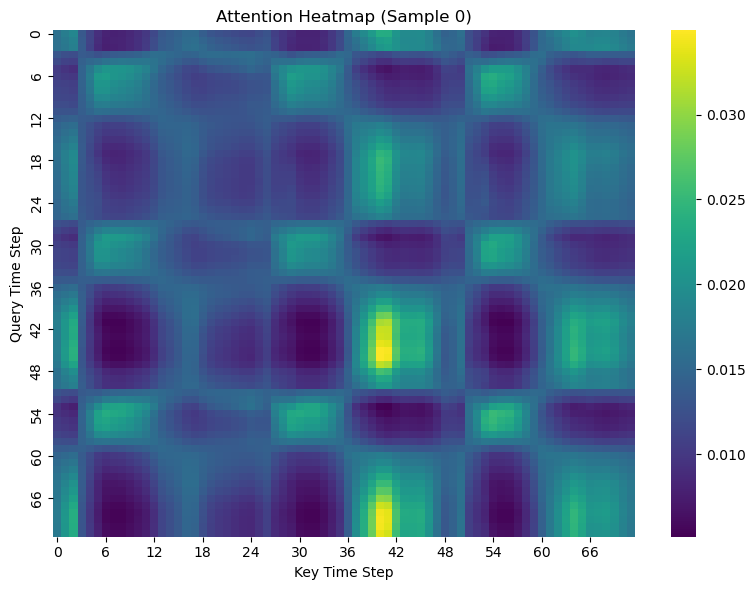

In [76]:
plot_attention_heatmap(attention_matrix, save_path = "../Report/5_13_heatmap.png")

# 5.14 The Necessity of Positional Encoding

In [2]:
import torch
import torch.nn as nn
import math

class SimpleSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(x.size(-1))
        attn = torch.softmax(scores, dim=-1)

        out = torch.matmul(attn, V)
        return out

In [7]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attn = SimpleSelfAttention(d_model)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Linear(d_model * 2, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x

In [8]:
class TransformerRegressor(nn.Module):
    def __init__(self, d_input=8, d_model=32, num_layers=2, use_positional=False):
        super().__init__()

        self.use_positional = use_positional

        self.input_proj = nn.Linear(d_input, d_model)
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model) for _ in range(num_layers)]
        )

        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B, 72, 8)

        x = self.input_proj(x)

        if self.use_positional:
            x = x + sinusoidal_positional_encoding(x.size(1), x.size(2)).to(x.device)

        for layer in self.encoder_layers:
            x = layer(x)

        # Mean pooling
        x = x.mean(dim=1)

        out = self.fc(x)
        return out

In [9]:
def sinusoidal_positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)

    position = torch.arange(0, seq_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    return pe.unsqueeze(0)  # (1, seq_len, d_model)

In [14]:
def train_attention_model(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    lr=5e-4,
    patience=10,
    min_delta=1e-6,
    device="cpu",
    save_checkpoint=False,
    checkpoint_path="best_attention_model.pt"
):
    model = model.to(device)

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    best_epoch = 0

    train_losses = []
    val_losses = []
    epoch_times = []

    for epoch in range(epochs):
        start_time = time.time()

        # ---- TRAIN ----
        model.train()
        optimizer.zero_grad()

        output = model(X_train)

        # Handle tuple vs single output
        preds = output[0] if isinstance(output, tuple) else output

        train_loss = criterion(preds, y_train)

        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # ---- VALIDATION ----
        model.eval()
        with torch.no_grad():
            output_val = model(X_val)
            val_preds = output_val[0] if isinstance(output_val, tuple) else output_val
            val_loss = criterion(val_preds, y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1:03d} | Train: {train_loss.item():.4f} | Val: {val_loss.item():.4f}")

        # ---- EARLY STOPPING + CHECKPOINT ----
        if val_loss.item() < best_val_loss - min_delta:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            best_epoch = epoch

            if save_checkpoint:
                if os.path.dirname(checkpoint_path):
                    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
                torch.save(best_model_state, checkpoint_path)

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"Best model at epoch {best_epoch+1}")
            break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    return {
        "model": model,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "avg_epoch_time": avg_epoch_time
    }

In [10]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase5_data = get_phase5_data(input_columns, target_columns, sliding_window = 72, time_steps = 24)
std_scaler_data, std_scaler_target = phase5_data['std_scalers'] # Needed to re-construct the original values

X_train, y_train = phase5_data['train']
X_val, y_val = phase5_data['val']
X_test, y_test = phase5_data['test']

X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
X_val = torch.tensor(X_val, dtype = torch.float32).to(device)
X_test = torch.tensor(X_test, dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

Standard Scaler applied on Data.

Input Data Shape: (18776, 8)
Input Target Shape: (18776, 1)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143, 1)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817, 1)
Test Data Shape: (2816, 8)
Test Target Shape: (2816, 1)

########## Dimensions After Flattening ##########

Train Data Shape: (13047, 72, 8)
Train Target Shape: (13047, 1)
Validation Data Shape: (2721, 72, 8)
Validation Target Shape: (2721, 1)
Test Data Shape: (2720, 72, 8)
Test Target Shape: (2720, 1)


In [15]:
save_dir = "../Models"
model_num = 1
model_save_path = os.path.join(save_dir, f"5_14_{model_num}_no_pe.pth")

model_no_pe = TransformerRegressor(
    d_input=8,
    d_model=32,
    num_layers=2,
    use_positional=False
)

results_no_pe = train_attention_model(
    model_no_pe,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    lr=1e-3,
    patience=10,
    device=device,
    save_checkpoint=True,
    checkpoint_path = model_save_path
)

print("Validation Loss (No PE):", results_no_pe["best_val_loss"])

Epoch 001 | Train: 0.9857 | Val: 0.3186
Epoch 002 | Train: 0.9113 | Val: 0.2809
Epoch 003 | Train: 0.8769 | Val: 0.2896
Epoch 004 | Train: 0.8520 | Val: 0.3049
Epoch 005 | Train: 0.8397 | Val: 0.3024
Epoch 006 | Train: 0.8273 | Val: 0.2864
Epoch 007 | Train: 0.8109 | Val: 0.2719
Epoch 008 | Train: 0.7958 | Val: 0.2670
Epoch 009 | Train: 0.7837 | Val: 0.2733
Epoch 010 | Train: 0.7736 | Val: 0.2902
Epoch 011 | Train: 0.7666 | Val: 0.3114
Epoch 012 | Train: 0.7633 | Val: 0.3239
Epoch 013 | Train: 0.7610 | Val: 0.3217
Epoch 014 | Train: 0.7574 | Val: 0.3110
Epoch 015 | Train: 0.7536 | Val: 0.3015
Epoch 016 | Train: 0.7508 | Val: 0.2978
Epoch 017 | Train: 0.7488 | Val: 0.2990
Epoch 018 | Train: 0.7476 | Val: 0.3013

Early stopping at epoch 18
Best model at epoch 8
Validation Loss (No PE): 0.26700854301452637


In [17]:
save_dir = "../Models"
model_num = 1
model_save_path = os.path.join(save_dir, f"5_14_{model_num}_pe.pth")

model_pe = TransformerRegressor(
    d_input=8,
    d_model=32,
    num_layers=2,
    use_positional=True
)

results_pe = train_attention_model(
    model_pe,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    lr=5e-4,
    patience=10,
    device=device,
    save_checkpoint=True,
    checkpoint_path=model_save_path
)

print("Validation Loss (With PE):", results_pe["best_val_loss"])

Epoch 001 | Train: 1.1162 | Val: 0.6127
Epoch 002 | Train: 1.0550 | Val: 0.4845
Epoch 003 | Train: 1.0113 | Val: 0.4084
Epoch 004 | Train: 0.9760 | Val: 0.3666
Epoch 005 | Train: 0.9446 | Val: 0.3451
Epoch 006 | Train: 0.9165 | Val: 0.3354
Epoch 007 | Train: 0.8929 | Val: 0.3311
Epoch 008 | Train: 0.8748 | Val: 0.3254
Epoch 009 | Train: 0.8625 | Val: 0.3139
Epoch 010 | Train: 0.8547 | Val: 0.2972
Epoch 011 | Train: 0.8494 | Val: 0.2801
Epoch 012 | Train: 0.8461 | Val: 0.2672
Epoch 013 | Train: 0.8441 | Val: 0.2599
Epoch 014 | Train: 0.8421 | Val: 0.2571
Epoch 015 | Train: 0.8388 | Val: 0.2573
Epoch 016 | Train: 0.8340 | Val: 0.2593
Epoch 017 | Train: 0.8282 | Val: 0.2621
Epoch 018 | Train: 0.8220 | Val: 0.2643
Epoch 019 | Train: 0.8156 | Val: 0.2647
Epoch 020 | Train: 0.8090 | Val: 0.2635
Epoch 021 | Train: 0.8027 | Val: 0.2617
Epoch 022 | Train: 0.7969 | Val: 0.2608
Epoch 023 | Train: 0.7920 | Val: 0.2619
Epoch 024 | Train: 0.7877 | Val: 0.2654

Early stopping at epoch 24
Best model a

# 5.15 Vision Transformer (ViT)

In [77]:
#########  STRATIFIED SAMPLING  #########

def stratified_split(dataset, random_state=42):
    indices = list(range(len(dataset)))
    labels = dataset.labels

    # Step 1: Train (70) vs Temp (30)
    train_idx, temp_idx = train_test_split(
        indices,
        test_size=0.3,
        stratify=labels,
        random_state=random_state
    )

    # Labels for temp split
    temp_labels = [labels[i] for i in temp_idx]

    # Step 2: Temp → Val (15) + Test (15)
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        stratify=temp_labels,
        random_state=random_state
    )

    return train_idx, val_idx, test_idx

In [78]:
#########  DATASET CLASS  #########

class PlantVillageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.labels_to_index = {}
        self.index_to_labels = {}
        self.samples = []
        self.labels = []   # needed for stratified split

        self.valid_extensions = (".jpg",".jpeg", ".png")
        
        # List of class names (folders in the root directory)
        class_names = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))])

        for labels_index,class_name in enumerate(class_names):
            class_dir = os.path.join(root_dir, class_name)
            self.labels_to_index[class_name] = labels_index
            self.index_to_labels[labels_index] = class_name

            for file_name in os.listdir(class_dir):
                if not file_name.lower().endswith(self.valid_extensions):
                    continue

                path = os.path.join(class_dir, file_name)
                if not os.path.isfile(path):
                    continue
                    
                self.samples.append((path, labels_index))
                self.labels.append(labels_index)
            
    def __len__(self):
        return len(self.samples)

    def num_classes(self):
        return len(self.labels_to_index)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [79]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_channels=3, d_model=128):
        super().__init__()

        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size

        self.proj = nn.Linear(self.patch_dim, d_model)

    def forward(self, x):
        # x: (B, 3, 128, 128)

        B, C, H, W = x.shape
        P = self.patch_size

        # Step 1: split into patches
        x = x.unfold(2, P, P).unfold(3, P, P)
        # (B, C, 8, 8, 16, 16)

        x = x.contiguous().view(B, C, -1, P, P)
        # (B, C, 64, 16, 16)

        x = x.permute(0, 2, 1, 3, 4)
        # (B, 64, 3, 16, 16)

        x = x.reshape(B, self.num_patches, -1)
        # (B, 64, 768)

        x = self.proj(x)
        # (B, 64, d_model)

        return x

In [80]:
def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    pos = torch.arange(0, seq_len).unsqueeze(1)

    div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))

    pe[:, 0::2] = torch.sin(pos * div_term)
    pe[:, 1::2] = torch.cos(pos * div_term)

    return pe.unsqueeze(0)  # (1, seq_len, d_model)

In [81]:
class ViT(nn.Module):
    def __init__(self, num_classes, d_model=128, num_layers=2):
        super().__init__()

        self.patch_embed = PatchEmbedding(d_model=d_model)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model) for _ in range(num_layers)]
        )

        self.cls_head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (B, 3, 128, 128)

        x = self.patch_embed(x)  # (B, 64, d_model)

        pe = positional_encoding(x.size(1), x.size(2)).to(x.device)
        x = x + pe

        for layer in self.encoder_layers:
            x = layer(x)

        x = x.mean(dim=1)  # global pooling

        out = self.cls_head(x)
        return out

In [82]:
base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# root_dir= '../plantvillage dataset/segmented'
root_dir= '../plantvillage dataset/color'
train_batch_size = 128
test_batch_size = 64
dataset = PlantVillageDataset(root_dir, transform=base_transform)

train_idx, val_idx, test_idx = stratified_split(dataset)
hundred_test_idx = np.random.choice(test_idx, size = 100, replace= False)

train_dataset = Subset(dataset, train_idx)
val_dataset   = Subset(dataset, val_idx)
test_dataset  = Subset(dataset, hundred_test_idx)


train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
    # num_workers=2,
    # pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False
    # num_workers=2,
    # pin_memory=True
)

In [83]:
def train_vit(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=3e-4,
    patience=8,
    min_delta=1e-4,
    device="mps",
    save_checkpoint=True,
    checkpoint_path="checkpoints/vit_best.pt",
    verbose=True
):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    best_epoch = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        start_time = time.time()

        # ---- TRAIN ----
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_acc = correct / total

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        epoch_time = time.time() - start_time

        if verbose:
            print(
                f"Epoch {epoch+1:03d} | "
                f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                f"Time: {epoch_time:.2f}s"
            )

        # ---- EARLY STOPPING + CHECKPOINT ----
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            best_epoch = epoch

            if save_checkpoint:
                if os.path.dirname(checkpoint_path):
                    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

                torch.save(best_model_state, checkpoint_path)

                # if verbose:
                #     print(f"  → Saved best model at epoch {epoch+1}")

        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                print(f"Best model was at epoch {best_epoch+1}")
            break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "model": model,
        "history": history,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch + 1
    }

In [52]:
save_dir = "../Models"
model_num = 2
model_save_path = os.path.join(save_dir, f"5_15_{model_num}.pth")

model = ViT(num_classes=dataset.num_classes(), d_model=128, num_layers=2)

results = train_vit(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=5e-4,
    patience=8,
    device=device,
    save_checkpoint=True,
    checkpoint_path = model_save_path,
    verbose=True
)

trained_model = results["model"]

print("\nBest Validation Loss:", results["best_val_loss"])
print("Best Epoch:", results["best_epoch"])

Epoch 001 | Train Loss: 2.3165, Acc: 0.3748 | Val Loss: 1.6417, Acc: 0.5393 | Time: 42.51s
Epoch 002 | Train Loss: 1.4235, Acc: 0.5852 | Val Loss: 1.1791, Acc: 0.6512 | Time: 42.27s
Epoch 003 | Train Loss: 1.0747, Acc: 0.6823 | Val Loss: 0.9715, Acc: 0.7030 | Time: 40.66s
Epoch 004 | Train Loss: 0.8442, Acc: 0.7474 | Val Loss: 0.7710, Acc: 0.7661 | Time: 39.94s
Epoch 005 | Train Loss: 0.6966, Acc: 0.7854 | Val Loss: 0.6337, Acc: 0.8063 | Time: 41.12s
Epoch 006 | Train Loss: 0.5932, Acc: 0.8182 | Val Loss: 0.5549, Acc: 0.8323 | Time: 40.96s
Epoch 007 | Train Loss: 0.5127, Acc: 0.8402 | Val Loss: 0.4837, Acc: 0.8491 | Time: 40.43s
Epoch 008 | Train Loss: 0.4575, Acc: 0.8580 | Val Loss: 0.4362, Acc: 0.8642 | Time: 40.99s
Epoch 009 | Train Loss: 0.4213, Acc: 0.8683 | Val Loss: 0.4187, Acc: 0.8674 | Time: 39.68s
Epoch 010 | Train Loss: 0.3862, Acc: 0.8769 | Val Loss: 0.3640, Acc: 0.8839 | Time: 40.89s
Epoch 011 | Train Loss: 0.3568, Acc: 0.8862 | Val Loss: 0.3648, Acc: 0.8842 | Time: 40.22s

In [84]:
def load_model(model_class,num_classes, model_path, device):
    model = model_class(num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

In [45]:
num_classes = dataset.num_classes()
model = load_model(ViT, num_classes, model_save_path, device)

results = train_vit(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=3e-4,
    patience=8,
    device=device,
    save_checkpoint=True,
    checkpoint_path = model_save_path,
    verbose=True
)

trained_model = results["model"]

print("\nBest Validation Loss:", results["best_val_loss"])
print("Best Epoch:", results["best_epoch"])

Epoch 001 | Train Loss: 0.2432, Acc: 0.9187 | Val Loss: 0.4271, Acc: 0.8693 | Time: 47.99s
Epoch 002 | Train Loss: 0.2318, Acc: 0.9228 | Val Loss: 0.4513, Acc: 0.8639 | Time: 40.03s
Epoch 003 | Train Loss: 0.2263, Acc: 0.9243 | Val Loss: 0.4275, Acc: 0.8656 | Time: 39.01s
Epoch 004 | Train Loss: 0.2172, Acc: 0.9274 | Val Loss: 0.4277, Acc: 0.8695 | Time: 39.41s
Epoch 005 | Train Loss: 0.2125, Acc: 0.9302 | Val Loss: 0.4488, Acc: 0.8632 | Time: 39.39s
Epoch 006 | Train Loss: 0.2070, Acc: 0.9320 | Val Loss: 0.4327, Acc: 0.8693 | Time: 38.89s
Epoch 007 | Train Loss: 0.2022, Acc: 0.9312 | Val Loss: 0.4419, Acc: 0.8669 | Time: 39.09s
Epoch 008 | Train Loss: 0.1959, Acc: 0.9344 | Val Loss: 0.4157, Acc: 0.8770 | Time: 39.40s
Epoch 009 | Train Loss: 0.1895, Acc: 0.9368 | Val Loss: 0.5053, Acc: 0.8510 | Time: 40.53s
Epoch 010 | Train Loss: 0.1843, Acc: 0.9387 | Val Loss: 0.4265, Acc: 0.8742 | Time: 41.01s
Epoch 011 | Train Loss: 0.1770, Acc: 0.9410 | Val Loss: 0.4233, Acc: 0.8734 | Time: 40.51s

In [93]:
def count_params(model): 
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [88]:
def evaluate_model(model, dataloader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print("Correct:", correct)
    print("Total:", total)
    
    return accuracy

In [91]:
# hundred_test_idx = np.random.choice(test_idx, size = 100, replace= False)

save_dir = "../Models"
model_num = 2
model_save_path = os.path.join(save_dir, f"5_15_{model_num}.pth")

test_dataset  = Subset(dataset, test_idx)
num_classes = dataset.num_classes()

model = load_model(ViT, num_classes, model_save_path, device)

vit_params = count_params(model)
test_loader_base = DataLoader( test_dataset, batch_size=32, shuffle=False)
test_accuracy = evaluate_model(model, test_loader_base, device)

print(f"Test Accuracy : {test_accuracy:.6f}")
print("Number of Params:", vit_params)
print(f"Accuracy per Parameter : {test_accuracy/vit_params:.6f}")

Correct: 7617
Total: 8146
Test Accuracy : 0.935060
Number of Params: 335270
Accuracy per Parameter : 0.000003
